# Notebook 03: Power Analysis

### Purpose
- Evaluates the sensitivity of this experiment: what effects could it reliably detect, and what would it take to detect smaller ones?
- Connects statistical power directly to business decisions about experiment runtime and sample size requirements.

### Objectives
- Compute the minimum detectable effect (MDE) for visit rate, conversion rate, and spend at the actual sample size.
- Plot power curves and sample size curves to visualize the tradeoffs between precision, sample size, and runtime.
- Demonstrate how spend's skewed distribution limits power relative to binary outcomes, and quantify the improvement from winsorization.
- Translate results into a concrete design recommendation: the sample size and runtime a business would need to detect a given lift.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [5]:
hillstrom_df = pd.read_csv("../data/raw/hillstrom.csv")

hillstrom_df

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
63995,10,2) $100 - $200,105.54,1,0,Urban,0,Web,Mens E-Mail,0,0,0.0
63996,5,1) $0 - $100,38.91,0,1,Urban,1,Phone,Mens E-Mail,0,0,0.0
63997,6,1) $0 - $100,29.99,1,0,Urban,1,Phone,Mens E-Mail,0,0,0.0
63998,1,5) $500 - $750,552.94,1,0,Surburban,1,Multichannel,Womens E-Mail,0,0,0.0


## MDE for visit rate, conversion rate, and spend

In [ ]:
comparisons = [
    ("Mens E-Mail", "No E-Mail"),
    ("Womens E-Mail", "No E-Mail"),
    ("Mens E-Mail", "Womens E-Mail")
]

visit_counts_df = hillstrom_df.groupby("segment")["visit"].agg(["sum", "count"])

results = []

for group1, group2 in comparisons:

    p1 = visit_counts_df.loc[group1, "sum"] / visit_counts_df.loc[group1, "count"]
    p2 = visit_counts_df.loc[group2, "sum"] / visit_counts_df.loc[group2, "count"]

    n1 = visit_counts_df.loc[group1, "count"]
    n2 = visit_counts_df.loc[group2, "count"]

    var = (p1 * (1 - p1) / n1) + (p2 * (1 - p2) / n2)

    se = np.sqrt(var)

    z_alpha = 1.96  # for α=0.05
    z_beta = 0.84   # for 80% power
    
    mde = se * (z_alpha + z_beta)

    results.append((group1, group2, mde))

results_df = pd.DataFrame(results, columns=["Group 1", "Group 2", "MDE"])
display(results_df)

,Group 1,Group 2,MDE
0,Mens E-Mail,No E-Mail,0.009480
1,Womens E-Mail,No E-Mail,0.009056
2,Mens E-Mail,Womens E-Mail,0.010102


In [17]:
conversion_counts_df = hillstrom_df.groupby("segment")["conversion"].agg(["sum", "count"])

results = []

for group1, group2 in comparisons:

    p1 = conversion_counts_df.loc[group1, "sum"] / conversion_counts_df.loc[group1, "count"]
    p2 = conversion_counts_df.loc[group2, "sum"] / conversion_counts_df.loc[group2, "count"]

    n1 = conversion_counts_df.loc[group1, "count"]
    n2 = conversion_counts_df.loc[group2, "count"]

    var = (p1 * (1 - p1) / n1) + (p2 * (1 - p2) / n2)

    se = np.sqrt(var)

    z_alpha = 1.96
    z_beta = 0.84

    mde = se * (z_alpha + z_beta)

    results.append((group1, group2, mde))
    
results_df = pd.DataFrame(results, columns=["Group 1", "Group 2", "MDE"])
display(results_df)

,Group 1,Group 2,MDE
0,Mens E-Mail,No E-Mail,0.002578
1,Womens E-Mail,No E-Mail,0.002303
2,Mens E-Mail,Womens E-Mail,0.002786


In [20]:
results = []
for group1, group2 in comparisons:

    spend1 = hillstrom_df[hillstrom_df["segment"] == group1]["spend"]
    spend2 = hillstrom_df[hillstrom_df["segment"] == group2]["spend"]

    n1 = len(spend1)
    n2 = len(spend2)

    var1 = np.sum((spend1 - spend1.mean()) ** 2) / (n1 - 1)
    var2 = np.sum((spend2 - spend2.mean()) ** 2) / (n2 - 1)

    se = np.sqrt(var1 / n1 + var2 / n2)

    z_alpha = 1.96
    z_beta = 0.84

    mde = se * (z_alpha + z_beta)

    results.append((group1, group2, mde))

results_df = pd.DataFrame(results, columns=["Group 1", "Group 2", "MDE"])

results_df

,Group 1,Group 2,MDE
0,Mens E-Mail,No E-Mail,0.406690
1,Womens E-Mail,No E-Mail,0.364932
2,Mens E-Mail,Womens E-Mail,0.446929


## Power curves

Raw spend MDE:         $0.4067
Winsorized spend MDE:  $0.3205
Variance reduction:    36.2%
MDE reduction:         21.2%


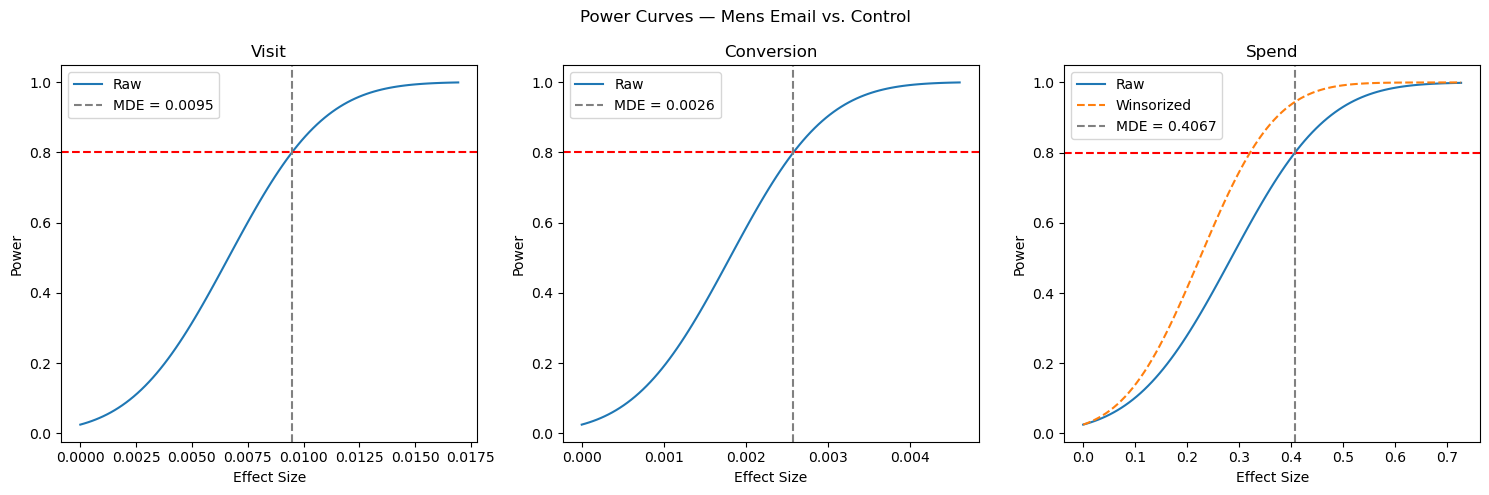

In [55]:
# visit

n1_visit = hillstrom_df[hillstrom_df["segment"] == "Mens E-Mail"]["visit"].count()
n2_visit = hillstrom_df[hillstrom_df["segment"] == "No E-Mail"]["visit"].count()

p1_visit = hillstrom_df[hillstrom_df["segment"] == "Mens E-Mail"]["visit"].sum() / n1_visit
p2_visit = hillstrom_df[hillstrom_df["segment"] == "No E-Mail"]["visit"].sum() / n2_visit

var_data_visit1 = p1_visit * (1 - p1_visit)
var_data_visit2 = p2_visit * (1 - p2_visit)

var_est_diff_visit = (var_data_visit1 / n1_visit) + (var_data_visit2 / n2_visit)

se_diff_visit = np.sqrt(var_est_diff_visit)


# conversion

n1_conversion = hillstrom_df[hillstrom_df["segment"] == "Mens E-Mail"]["conversion"].count()
n2_conversion = hillstrom_df[hillstrom_df["segment"] == "No E-Mail"]["conversion"].count()

p1_conversion = hillstrom_df[hillstrom_df["segment"] == "Mens E-Mail"]["conversion"].sum() / n1_conversion
p2_conversion = hillstrom_df[hillstrom_df["segment"] == "No E-Mail"]["conversion"].sum() / n2_conversion

var_data_conversion1 = p1_conversion * (1 - p1_conversion)
var_data_conversion2 = p2_conversion * (1 - p2_conversion)

var_est_diff_conversion = (var_data_conversion1 / n1_conversion) + (var_data_conversion2 / n2_conversion)

se_diff_conversion = np.sqrt(var_est_diff_conversion)


# spend

n1_spend = hillstrom_df[hillstrom_df["segment"] == "Mens E-Mail"]["spend"].count()
n2_spend = hillstrom_df[hillstrom_df["segment"] == "No E-Mail"]["spend"].count()

spend1 = hillstrom_df[hillstrom_df["segment"] == "Mens E-Mail"]["spend"]
spend2 = hillstrom_df[hillstrom_df["segment"] == "No E-Mail"]["spend"]

var_data_spend1 = np.sum((spend1 - spend1.mean()) ** 2) / (n1_spend - 1)
var_data_spend2 = np.sum((spend2 - spend2.mean()) ** 2) / (n2_spend - 1)

se_diff_spend = np.sqrt(var_data_spend1 / n1_spend + var_data_spend2 / n2_spend)

# winsorized

cap_value = hillstrom_df["spend"].quantile(0.999)
spend1_w = np.clip(spend1, 0, cap_value)
spend2_w = np.clip(spend2, 0, cap_value)

var_data_spend1_w = spend1_w.var()
var_data_spend2_w = spend2_w.var()

# Winsorization impact — quantifying the variance reduction and what it means for MDE

se_diff_spend_w = np.sqrt(var_data_spend1_w / n1_spend + var_data_spend2_w / n2_spend)

mde_raw = se_diff_spend * (z_alpha + z_beta)
mde_w = se_diff_spend_w * (z_alpha + z_beta)

variance_reduction = (1 - var_data_spend2_w / var_data_spend2) * 100
mde_reduction = (1 - mde_w / mde_raw) * 100

print(f"Raw spend MDE:         ${mde_raw:.4f}")
print(f"Winsorized spend MDE:  ${mde_w:.4f}")
print(f"Variance reduction:    {variance_reduction:.1f}%")
print(f"MDE reduction:         {mde_reduction:.1f}%")



# Plot

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (metric, se) in zip(axes, [("Visit", se_diff_visit), ("Conversion", se_diff_conversion), ("Spend", se_diff_spend)]):
    
    z_alpha = 1.96
    effect_sizes = np.linspace(0, 5 * se, 100)
    powers = [1 - stats.norm.cdf(z_alpha - (effect_size / se)) for effect_size in effect_sizes]
    mde = se * (z_alpha + z_beta)

    ax.plot(effect_sizes, powers, label="Raw")
    if metric == "Spend":
        powers_w = [1 - stats.norm.cdf(z_alpha - (effect_size / se_diff_spend_w)) for effect_size in effect_sizes]
        ax.plot(effect_sizes, powers_w, linestyle="--", label="Winsorized")
    ax.axhline(0.8, color="red", linestyle="--")
    ax.axvline(mde, color="gray", linestyle="--", label=f"MDE = {mde:.4f}")
    ax.set_title(metric)
    ax.set_xlabel("Effect Size")
    ax.set_ylabel("Power")
    ax.legend()

plt.suptitle("Power Curves — Mens Email vs. Control")
plt.tight_layout()
plt.show()


## Sample size curves

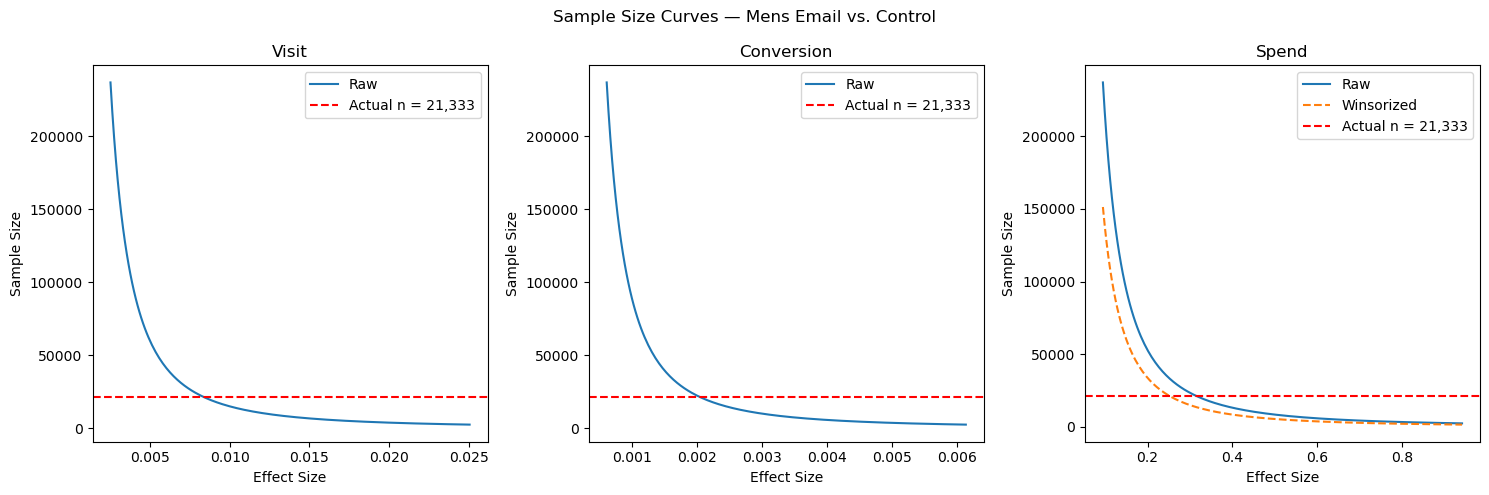

In [48]:
# Plot
# 4. Plot sample size curves: required sample size as a function of MDE

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (metric, var_control) in zip(axes, [("Visit", var_data_visit2), ("Conversion", var_data_conversion2), ("Spend", var_data_spend2)]):
    
    z_alpha = 1.96
    z_beta = 0.84

    mde_actual = (z_alpha + z_beta) * np.sqrt((2 * var_control) / 21333)
    mdes = np.linspace(mde_actual * 0.3, mde_actual * 3, 200)
    ns = [(2 * var_control * (z_alpha + z_beta)**2) / mde**2 for mde in mdes]

    ax.plot(mdes, ns, label="Raw")
    if metric == "Spend":
        ns_w = [((z_alpha + z_beta)**2 * (2 * var_data_spend2_w)) / mde**2 for mde in mdes]
        ax.plot(mdes, ns_w, linestyle="--", label="Winsorized")
    n_actual = 21333  # actual n per arm
    ax.axhline(n_actual, color="red", linestyle="--", label=f"Actual n = {n_actual:,}")
    ax.set_title(metric)
    ax.set_xlabel("Effect Size")
    ax.set_ylabel("Sample Size")
    ax.legend()

plt.suptitle("Sample Size Curves — Mens Email vs. Control")
plt.tight_layout()
plt.show()

## Relative lift required for MDE

In [54]:
control = hillstrom_df[hillstrom_df["segment"] == "No E-Mail"]
baselines = control[["visit", "conversion", "spend"]].mean()

mdes = {"visit": 0.0095, "conversion": 0.0026, "spend": 0.41}

for metric, mde in mdes.items():
    relative_lift = mde / baselines[metric]
    print(f"{metric}: MDE = {mde}, baseline = {baselines[metric]:.4f}, relative lift = {relative_lift:.1%}")

visit: MDE = 0.0095, baseline = 0.1062, relative lift = 8.9%
conversion: MDE = 0.0026, baseline = 0.0057, relative lift = 45.4%
spend: MDE = 0.41, baseline = 0.6528, relative lift = 62.8%


## Summary

- **MDE results** - the smallest effect this experiment could detect for each outcome metric at 80% power:
    - visit ~0.95pp
    - conversion ~0.26pp
    - spend ~$0.41
- The relative lift required for a MDE for conversion and spend are much larger than visit - not surprising given they are much rarer events
    - visit relative lift: 8.9%
    - conversion relative lift: 45.4%
    - spend relative lift: 62.8%
- Winsorization impact - reduces MDE (expected via variance reduction)
    - Raw spend MDE:         $0.4067
    - Winsorized spend MDE:  $0.3205
    - Variance reduction:    36.2%
    - MDE reduction:         21.2%
- **If the business only cares about spend effects of $0.50+, then experiments of this size will be adequately powered**
- **If a smaller lift is meaningful, e.g. $0.20 then the experiment will need to be run ~4.2x as long** (1/MDE^2 =~ (0.41/0.20)^2 =~ 4.2x)